In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_core.prompts import PromptTemplate

/home/narendra/Agentic AI/agentenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
class LLMState(TypedDict):
    title: str
    outline: str
    blog: str
    score: float

In [5]:
def create_outline(state: LLMState) -> LLMState:

    title = state["title"]

    template = PromptTemplate(
        template="create outline of this  : {title}",
        input_variables=["title"],
        validate_template=True,
    )

    prompt = template.invoke({"title": title})

    result = model.invoke(prompt)

    state["outline"] = result.content

    return state

In [6]:
def create_blog(state: LLMState) -> LLMState:

    outline = state["outline"]
    topic = state["title"]

    template = PromptTemplate(
        template="create blog of this topic : {title}  with using this outline : {outline}",
        input_variables=["outline", "title"],
        validate_template=True,
    )

    prompt = template.invoke({"title": topic, "outline": outline})

    result = model.invoke(prompt)
    
    state['blog']=result.content
    return state

In [7]:
def evalue_answer(state: LLMState) -> LLMState:

    blog = state["blog"]

    result = model.invoke(f"give score to this blog out of 10 , blog : {blog}").content

    state["score"] = result

    return state

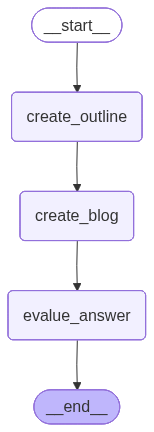

In [8]:
graph = StateGraph(LLMState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("evalue_answer", evalue_answer)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "evalue_answer")
graph.add_edge("evalue_answer", END)

workflow = graph.compile()
workflow

In [9]:
input_state = {"title": "poetry on Ahmedabad , gujrat, india"}

final_state = workflow.invoke(input_state)

final_state

{'title': 'poetry on Ahmedabad , gujrat, india',
 'outline': 'Here\'s an outline for a poem about Ahmedabad, Gujarat, India, designed to capture its multifaceted essence:\n\n---\n\n**Poem Title Idea:** *The Sabarmati\'s Song: Ahmedabad\'s Echoes* or *City of Threads: Ahmedabad\'s Heartbeat*\n\n**Overall Tone/Mood:** Reverent, vibrant, nostalgic, appreciative of both history and modernity.\n\n---\n\n**I. Introduction: The Grand Arrival & First Impression**\n    *   **A. Setting the Scene:**\n        *   Golden light of dawn or dusk over the city.\n        *   The gentle flow of the Sabarmati River, a constant witness.\n        *   Sense of ancient whispers mingling with modern hum.\n    *   **B. Initial Hook:**\n        *   Ahmedabad: A name that resonates with history and life.\n        *   Heart of Gujarat, a vibrant pulse within India\'s vast tapestry.\n        *   A city of contrasts: old walls embracing new dreams.\n\n**II. Verse 1: The Walled City\'s Embrace - History & Heritage**